<a href="https://colab.research.google.com/github/SauravSG/Deep-Learning/blob/main/Hands_on_Regression_in_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Hands-on practicing Regression**

**Motive:** To apply the learnings of **Regression**. From generating synthetic dataset to training and testing the model. Along with this, plotting, saving and load the model. We'll go in detail as we proceed

##1. Setup

Here, we will:
* Import the necessary libraries
* Generate the dataset using synthetic dataset generator like **make_regression**. It is basically use to generate a random regression problem where we can define how many number of samples, number of features, number of targets, noise etc we want.
* We will have to move the data to tensors from array as we generated using the scikit-learn library. For this, we will be using **torch.tensor()**.
* Converting the dataset into a more cleaner tabular form using **pandas**.

In [1]:
# First thing first importing torch and nn as these are the lives of every model
import torch
from torch import nn

In [2]:
# Importing make_regression to generate random regression dataset in further cells
from sklearn.datasets import make_regression

In [3]:
# Setting up the device in the beginning so our whole flow stays consistent on one device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
# Creating the dataset
X, y = make_regression(n_samples = 1000, # -> number of samples i.e. the total number of rows
                       n_features = 3, # -> features in total
                       n_targets = 1, # -> number of target we want to be predicted based on the features
                       noise = 0.03, # -> little bit of noise so our model learns well
                       shuffle = True, # -> enabled shuffling for better training
                       random_state=42 # -> for reproducibility over the shuffled dataset
                       )

In [5]:
# Sanity check no.1 to see the shapes and dimensions based on our created dataset
X.shape, y.shape ,'\n', X.ndim, y.ndim

((1000, 3), (1000,), '\n', 2, 1)

In [6]:
X[:5] # here we would get the array type of data in float only

array([[-0.18912039, -1.33031363,  0.92165011],
       [-0.65332923, -0.47494531,  1.76545424],
       [-0.22485598,  0.07685188, -0.65000258],
       [ 0.57059867, -0.66262376, -0.76325916],
       [ 0.32787952, -0.12545426,  0.08589301]])

In [7]:
print(f'First 5 samples of X: \n {X[:5]} \n')
print(f'First 5 targets of y: \n {y[:5]}')

First 5 samples of X: 
 [[-0.18912039 -1.33031363  0.92165011]
 [-0.65332923 -0.47494531  1.76545424]
 [-0.22485598  0.07685188 -0.65000258]
 [ 0.57059867 -0.66262376 -0.76325916]
 [ 0.32787952 -0.12545426  0.08589301]] 

First 5 targets of y: 
 [-103.56461178  -57.31026366  -32.68906897  -17.93331784   24.17061885]


In [8]:
print(type(X), type(y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [9]:
# before conversion, the original data type is float64
X.dtype, y.dtype

(dtype('float64'), dtype('float64'))

In [10]:
X.device, y.device # at this point the X and y are on CPU

('cpu', 'cpu')

In [11]:
# converting float64 to float32 as tensors works better with float32
# We are using torch.tensor() in order to convert the array to tensor because tensor() creates an full copy of the original array and also allows to specify the data type
X = torch.tensor(X, dtype = torch.float32)
y = torch.tensor(y, dtype = torch.float32)

In [12]:
# now checking the data type after the conversion
X.dtype, y.dtype

(torch.float32, torch.float32)

In [13]:
X[:5] # -> here we would see the type as tensor in float32 because of conversion

tensor([[-0.1891, -1.3303,  0.9217],
        [-0.6533, -0.4749,  1.7655],
        [-0.2249,  0.0769, -0.6500],
        [ 0.5706, -0.6626, -0.7633],
        [ 0.3279, -0.1255,  0.0859]])

In [14]:
y[:5]

tensor([-103.5646,  -57.3103,  -32.6891,  -17.9333,   24.1706])

In [15]:
# converting to dataframe for cleaner visualization of our dataset

'''
So our dataset is like for example, every house say A, B, c, upto 1000 has 3 features and label(y) is like the price based on these 3 features
'''

import pandas as pd
df = pd.DataFrame(X, columns = ['X1', 'X2', 'X3'])
df["labels (y)"] = y
df


,X1,X2,X3,labels (y)
0,-0.189120,-1.330314,0.921650,-103.564613
1,-0.653329,-0.474945,1.765454,-57.310265
2,-0.224856,0.076852,-0.650003,-32.689068
3,0.570599,-0.662624,-0.763259,-17.933317
4,0.327880,-0.125454,0.085893,24.170618
...,...,...,...,...
995,-0.466495,0.996571,0.640480,52.307167
996,0.436739,0.198948,0.404295,69.698524
997,1.390208,0.817766,0.557810,218.211029
998,-1.252393,-0.012089,0.363632,-114.759880


In [16]:
type(X)

torch.Tensor

In [17]:
# Creating a train test split for model training and evaluation

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f'Imagine the dataset divided in 4 quarters A, B, C, D where A and C are the 1st and 3rd quarters of X side data where A is 80% and C is 20% hence the shapes becomes {X_train.shape} and {X_test.shape} and for B and D i.e. 2nd and 4th quarters, that is y side of data where B is 80% and D is 20% hence the shape is {y_train.shape} and {y_test.shape}')

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

Imagine the dataset divided in 4 quarters A, B, C, D where A and C are the 1st and 3rd quarters of X side data where A is 80% and C is 20% hence the shapes becomes torch.Size([800, 3]) and torch.Size([200, 3]) and for B and D i.e. 2nd and 4th quarters, that is y side of data where B is 80% and D is 20% hence the shape is torch.Size([800]) and torch.Size([200])


In [18]:
# Sanity check no.2 to see our training and testing data all are on the right device
X_train.device, y_train.device, X_test.device, y_test.device

(device(type='cuda', index=0),
 device(type='cuda', index=0),
 device(type='cuda', index=0),
 device(type='cuda', index=0))

In [19]:
# setup class model
class RegressionV0(nn.Module):

  def __init__(self):
    super().__init__()

    self.layer_stack = nn.Sequential(
            nn.Linear(in_features = 3, out_features = 32),
            nn.ReLU(),
            nn.Linear(in_features = 32, out_features = 32),
            nn.ReLU(),
            nn.Linear(in_features = 32, out_features = 1)
            )


  def forward(self, x):
    return self.layer_stack(x)

In [20]:
# Creating first instance

model_0 = RegressionV0().to(device) # making sure our new model also stays on right device
model_0

RegressionV0(
  (layer_stack): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [21]:
# Print model_0's state dict. We would get random values at this point since these are randomly generated weights and biases and the goal is to take these values close to original values via the training and testing
model_0.state_dict()

OrderedDict([('layer_stack.0.weight',
              tensor([[ 0.1418,  0.3488,  0.1526],
                      [-0.4512,  0.1698, -0.0185],
                      [-0.1965, -0.4114, -0.1312],
                      [ 0.5737, -0.4913, -0.1024],
                      [-0.5307,  0.2977,  0.3015],
                      [ 0.3230,  0.5237,  0.4621],
                      [ 0.3208, -0.4971, -0.5478],
                      [ 0.3503,  0.1338, -0.2884],
                      [ 0.1627, -0.5175,  0.0238],
                      [ 0.0384,  0.0561,  0.0451],
                      [-0.2754, -0.1436,  0.2169],
                      [-0.4204,  0.3876, -0.1602],
                      [ 0.2348, -0.4551, -0.1253],
                      [ 0.4888,  0.1132,  0.1626],
                      [ 0.4243, -0.0325, -0.4374],
                      [ 0.1032,  0.1338, -0.3441],
                      [ 0.3755, -0.0999,  0.0687],
                      [-0.3992, -0.5314, -0.2005],
                      [ 0.1581,  0.5413, -0.

In [22]:
# Setup loss function and optimizer
loss_fn = nn.L1Loss()

optimizer = torch.optim.Adam(params = model_0.parameters(), lr = 0.01)

In [23]:
# Building training and testing loop

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# The below three lists would be neccessary for plotting loss curve
epoch_count = []
loss_count = []
test_loss_count = []

# For epoch in a range
for epoch in range(epochs):

  ### Training

  # Putting our model into training mode
  model_0.train()

  # optimizer zerp grad so no history of previous gradients
  optimizer.zero_grad()

  # Do the forward pass
  y_pred = model_0(X_train)

  # We are squeezing the y_pred for the loss calculation part. The y_pred we'd get would be a 2D tensor and our y_pred is a 1D tensor. Hence squeezing would remove the extra dimension.
  y_pred = y_pred.squeeze()

  # Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # loss backward
  loss.backward()

  # apply the updated weights through optimzier.step()
  optimizer.step()

  ### Testing

  # Put the model into evaluation mode so no gradient tracking would be there
  model_0.eval()

  # We'll be using inference_mode context manager in this case
  with torch.inference_mode():

    # Do the forward pass
    test_pred = model_0(X_test)

    # Same reason. To make it compatible with y_test in loss_function
    test_pred = test_pred.squeeze()

    # Calculate the loss
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 100 == 0:
    epoch_count.append(epoch) # Printing epochs after every 100s
    loss_count.append(loss.item()) # We are itemizing otherwise we would be appending entire tensors with computational graph. We need plain value, hence itemizing.
    test_loss_count.append(test_loss.item()) # same reason as above

    print(f'Epoch: {epoch} | train loss: {loss:.4f} | test loss: {test_loss:.4f}') #-> # Lower loss = predictions closer to actual values — this is how we measure performance in regression

Epoch: 0 | train loss: 100.9128 | test loss: 102.9216
Epoch: 100 | train loss: 3.4026 | test loss: 3.3582
Epoch: 200 | train loss: 0.9287 | test loss: 1.3047
Epoch: 300 | train loss: 0.5830 | test loss: 0.5731
Epoch: 400 | train loss: 0.8439 | test loss: 1.0469
Epoch: 500 | train loss: 0.6259 | test loss: 1.0040
Epoch: 600 | train loss: 0.5655 | test loss: 0.8138
Epoch: 700 | train loss: 0.4289 | test loss: 0.7374
Epoch: 800 | train loss: 0.6579 | test loss: 0.3996
Epoch: 900 | train loss: 0.6637 | test loss: 0.5406


**Note:**

- We used inference_mode() instead of no_grad() as it is more strictier and faster than no_grad() because it also erases/disables version tracking of gradients

In [24]:
# We are doing this separately just to check how well our model predicted the values against the actual values

with torch.inference_mode():

    test_pred = model_0(X_test)
    test_pred = test_pred.squeeze()

    test_loss = loss_fn(test_pred, y_test)

print(f'First 5 preds: {test_pred[:5]} vs actual values {y_test[:5]}')

First 5 preds: tensor([-75.7415, 112.0854,  49.3718, 180.3654, -23.2111], device='cuda:0') vs actual values tensor([-76.4412, 111.3779,  49.2146, 179.2189, -24.2339], device='cuda:0')


In [25]:
# Checking the after training model's state_dict()
model_0.state_dict()

OrderedDict([('layer_stack.0.weight',
              tensor([[ 0.7063,  1.0233,  0.4790],
                      [-1.0749, -0.4578, -0.7549],
                      [-0.3355, -0.3314, -0.0276],
                      [ 1.3377,  0.1416,  0.3671],
                      [-0.9173, -0.0027,  0.3220],
                      [ 1.0289,  1.3167,  0.8338],
                      [-0.8920, -1.2960, -0.9011],
                      [ 0.4057,  0.2040, -0.0292],
                      [-0.7846, -1.1508,  0.3617],
                      [ 0.5405,  0.8396,  0.3583],
                      [-1.0128, -0.5872,  0.3773],
                      [-1.0525, -0.5452, -0.6978],
                      [-0.8611, -1.0607, -0.3938],
                      [ 1.0884,  0.4740,  0.7202],
                      [ 1.0666,  0.6145, -0.4032],
                      [ 0.2513,  0.3015, -0.1260],
                      [ 1.0197,  0.4515,  0.2915],
                      [-1.0224, -1.4563, -0.6617],
                      [ 0.9175,  1.3375, -0.

## **Plotting the predictions**

In [26]:
import matplotlib.pyplot as plt

def plot_predictionsV0(train_data = X_train.cpu().numpy(),
                       train_labels = y_train.cpu().numpy(),
                       test_data = X_test.cpu().numpy(),
                       test_labels = y_test.cpu().numpy(),
                       predictions = None):

  plt.figure(figsize=(10, 7))

  plt.scatter(train_data, train_labels, c='b', s = 4, label = 'training data')
  plt.scatter(test_data, test_labels, c='g', s = 4, label = 'testing data')
  if predictions is not None:
    plt.scatter(test_data, predictions, c = 'r', s = 4)
  plt.legend(prop={"size":14});

ValueError: x and y must be the same size

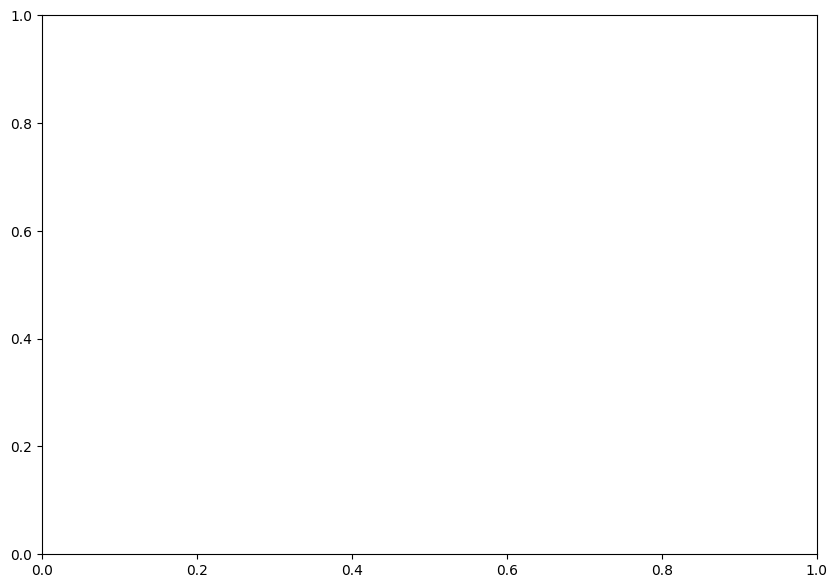

In [27]:
plot_predictionsV0()

In [29]:
y_pred.shape

torch.Size([800])

In [30]:
y_test.shape

torch.Size([200])

In [31]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([800, 3]),
 torch.Size([800]),
 torch.Size([200, 3]),
 torch.Size([200]))

The above plotting predicitions failed because this is a learning that for regressions with multiple features (hence making it 2D) is not possible against 1D tensor like the train and test labels

## **Plotting loss curve**

- Plotting the loss curve to see how well our model performed after every 100 epoch in case of both training and testing

In [35]:
def plot_loss_curve(epoch_count = epoch_count,
                    train_loss = loss_count,
                    test_loss = test_loss_count):

  plt.figure(figsize=(9, 6))

  plt.plot(epoch_count, train_loss, c = 'b', label = 'training loss')
  plt.plot(epoch_count, test_loss, c = 'r', label = 'test loss')
  plt.xlabel('epochs')
  plt.ylabel('loss')
  plt.title("Loss curve between epoch counts and the train loss and test loss")
  plt.legend(prop={"size":14});

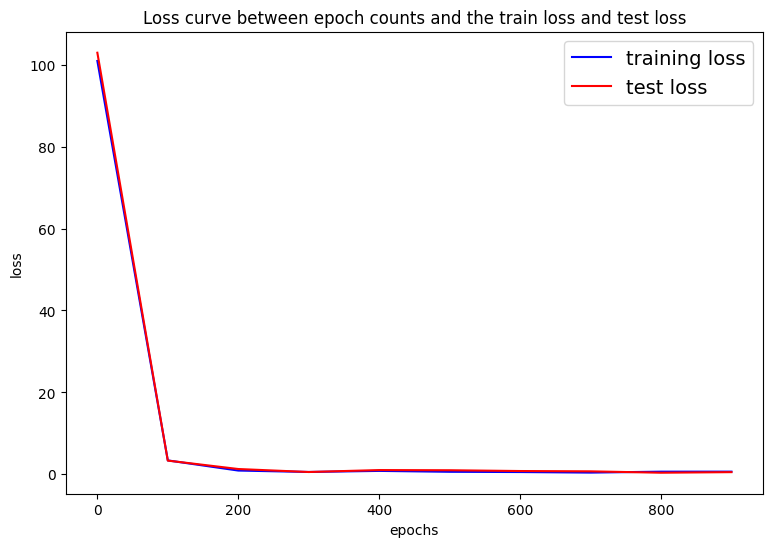

In [36]:
plot_loss_curve()

## **Saving the model**

In [37]:
from pathlib import Path

# To save a model, first we would need a directory and eventually a path
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# create a model name and save it in some model path
MODEL_NAME = 'Regression_model_0.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# save model_0's state dict. For this we would use torch.save()
print(f'Model saved to: {MODEL_SAVE_PATH}')
torch.save(obj = model_0.state_dict(), f = MODEL_SAVE_PATH)


Model saved to: models/Regression_model_0.pth


In [38]:
# Let's try loading the mdoel_0's state_dict() and try on X_test (again) using inference mode with new loaded model

model_0.state_dict()

OrderedDict([('layer_stack.0.weight',
              tensor([[ 0.7063,  1.0233,  0.4790],
                      [-1.0749, -0.4578, -0.7549],
                      [-0.3355, -0.3314, -0.0276],
                      [ 1.3377,  0.1416,  0.3671],
                      [-0.9173, -0.0027,  0.3220],
                      [ 1.0289,  1.3167,  0.8338],
                      [-0.8920, -1.2960, -0.9011],
                      [ 0.4057,  0.2040, -0.0292],
                      [-0.7846, -1.1508,  0.3617],
                      [ 0.5405,  0.8396,  0.3583],
                      [-1.0128, -0.5872,  0.3773],
                      [-1.0525, -0.5452, -0.6978],
                      [-0.8611, -1.0607, -0.3938],
                      [ 1.0884,  0.4740,  0.7202],
                      [ 1.0666,  0.6145, -0.4032],
                      [ 0.2513,  0.3015, -0.1260],
                      [ 1.0197,  0.4515,  0.2915],
                      [-1.0224, -1.4563, -0.6617],
                      [ 0.9175,  1.3375, -0.

In [39]:
# To load in a state_dict(), we have to instantiate a new instance of model_0 class

model_1 = RegressionV0().to(device)
model_1

RegressionV0(
  (layer_stack): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [40]:
# Loading the model_0's state_dict into newly created model, model_1.
model_1.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only = True))

<All keys matched successfully>

We'd only wish to have tensors values and no arbitary values. For this purpose we'll use `weights_only = True`.

In [42]:
# Check how well our model_1 predicts against actual values after loading model_0's state_dict() into model_1

model_1.eval()

with torch.inference_mode():

  testing_pred = model_1(X_test)
  testing_pred = testing_pred.squeeze()

  testing_loss = loss_fn(testing_pred, y_test)

  print(f'Predicted values: {testing_pred[:5]} vs actual values: {y_test[:5]}')
  print(f'original model loss : {testing_loss:.4f} vs loaded model loss: {test_loss:.4f}')

Predicted values: tensor([-75.7415, 112.0854,  49.3718, 180.3654, -23.2111], device='cuda:0') vs actual values: tensor([-76.4412, 111.3779,  49.2146, 179.2189, -24.2339], device='cuda:0')
original model loss : 0.7230 vs loaded model loss: 0.7230
